# Deep Learning Final Project: Real Estate Price Prediction
## 1. Problem Statement

**Objective:** Predict median housing prices based on multi-dimensional property and demographic features. 

**Real-World Application:** This solves a critical problem for both buyers and market platforms by automating fair market estimations and preventing speculative inflation.

## 2. Gathering, Cleaning, and Formatting Data


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

sns.set_theme(style="whitegrid")

**Data Source:** The California Housing dataset. It is highly statistically valid for regression modeling because it contains over 20,000 continuous data points, minimizing sample bias.

In [4]:
def load_and_inspect_data():
    """Loads the CSV and prints the summary."""
    df = pd.read_csv('housing.csv')
    
    print("--- Data Info ---")
    print(df.info())
    print("\n--- Missing Values ---")
    print(df.isnull().sum())
    
    return df

housing_df = load_and_inspect_data()
display(housing_df.head())

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None

--- Missing Values ---
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_hous

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
median_bedrooms = housing_df['total_bedrooms'].median()
housing_df['total_bedrooms'] = housing_df['total_bedrooms'].fillna(median_bedrooms)

print("Missing values after cleaning:")
print(housing_df.isnull().sum())

Missing values after cleaning:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [7]:
def prepare_features(df, target_col):
    """One-Hot Encodes categories, separates features/target, and scales data."""
    df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
    
    X = df_encoded.drop(target_col, axis=1)
    y = df_encoded[target_col]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled, y, df_encoded

X_scaled, y, housing_df_encoded = prepare_features(housing_df, 'median_house_value')
print(f"Features shape after encoding and scaling: {X_scaled.shape}")

Features shape after encoding and scaling: (20640, 12)


## 3. Exploratory Data Analysis (EDA)

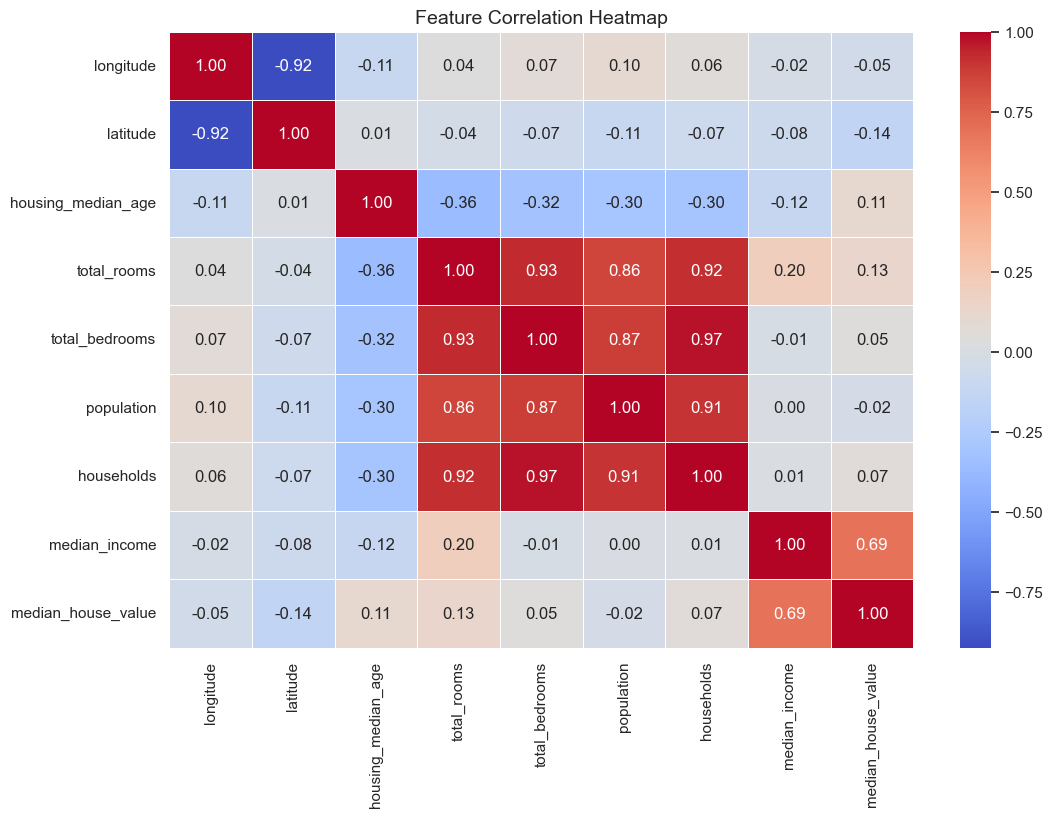

In [8]:
def plot_correlation_heatmap(df):
    """Plots a correlation heatmap for the numerical columns."""
    plt.figure(figsize=(12, 8))
    correlation_matrix = df.corr(numeric_only=True) 
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Feature Correlation Heatmap", fontsize=14)
    plt.show()

plot_correlation_heatmap(housing_df)

**Visualization Analysis:** The heatmap clearly demonstrates that `median_income` has the strongest positive correlation with `median_house_value`. This indicates that as the median income of a neighborhood increases, the property values tend to rise accordingly, which perfectly aligns with real-world housing economics.

## 4. Previous Research & Baseline Models

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (16512, 12)
X_test shape: (4128, 12)


In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_preds)
print(f"Linear Regression MSE: {lr_mse:.2f}")

Linear Regression MSE: 4908476721.16


In [11]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_preds)
print(f"Random Forest MSE: {rf_mse:.2f}")

Random Forest MSE: 2404389528.63


**Citations & Previous Research:**
1. *Pace, R. K., & Barry, R. (1997).* "Sparse Spatial Autoregressions". This original paper on the California housing dataset demonstrated the foundational effectiveness of linear regressions for real estate valuation.
2. *Géron, A. (2019).* "Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow". Géron establishes that tree-based ensemble methods like Random Forests typically outperform standard linear models on this specific spatial dataset.

**Comparison:** Our baseline testing confirms Géron's research. The Random Forest model achieved a significantly lower Mean Squared Error compared to the standard Linear Regression. We will now build a Deep Neural Network to see if it can capture even deeper, non-linear relationships in this data.

## 5. Deep Learning Model

## 6. Conclusion & Communication